Here we consider the task of assimilating observations of the Lorenz-96 systems that are irregularly sampled in time.This problem is conceptually more complex than the standard conditions with a fixed time step. We address it successively with strong- and weak-constraint 4D-Var and finally with an ensemble Kalman filter.

For strong-constraint 4D-Var and EnKF, the resolution of this problem is only marginally different from the special case with a fixed time step. For weak-constraint, it is slightly more complicated since it requires interpolating the regular grid of the optimized state to the irregularly-sampled observation timestamps.

The system state is composed of $N$ variables $x_1, ..., x_N$ with periodic boundaries (i.e. $x_{N+1} = x_{1}, x_{0} = x_N, x_{-1} = x_{N-1}$).

For $i=1, ..., N$, its evolution is described by:

$\frac{dx_i}{dt} = (x_{i+1} - x_{i-2}) x_{i-1} - x_i + F$

We will use the most common choices $N=40$ and $F=8$.

# Generate a groundtruth irregularly-sampled time-series and associated observation set

Here, contrarily to standard practice, we solve the Lorenz-96 equations with a numerical scheme (Runge-Kutta 4) with irregularly-sampled time steps

In [1]:
import os
import torch
from matplotlib import pyplot as plt
from time import time
from tensordict import TensorDict
from mdml_sim.lorenz96 import L96Simulator
import numpy as np
os.chdir('..')
from adda.variational.strong_constraint_4dvar import sc4dvar_single_window
from adda.variational.weak_constraint_4dvar import wc4dvar_single_window
from adda.ensemble.enkf import EnKF, enkf
from adda.system.state import State
from adda.observation.operators import random_sparse_noisy_obs, MaskedIidGaussianTimeInterpolatedObsOp
from adda.util.initialization import naive_initialization
from adda.util.visualization import show_1dseqimg, show_1dseqimg_irregular_time
from adda.probability.distributions import DiagonalGaussian

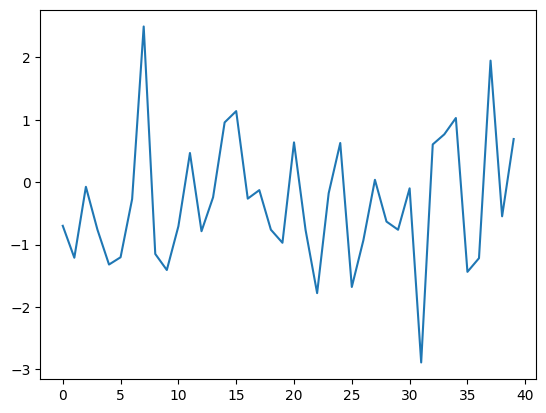

In [2]:
# Define a target initial state
n_variables = 40 # N = 40
initial_state = State(torch.randn(1, 1, n_variables))  # (batch, time, n_variables)
plt.plot(initial_state.fields['x'].squeeze())

torch.Size([1200, 40])
tensor(3.9710)


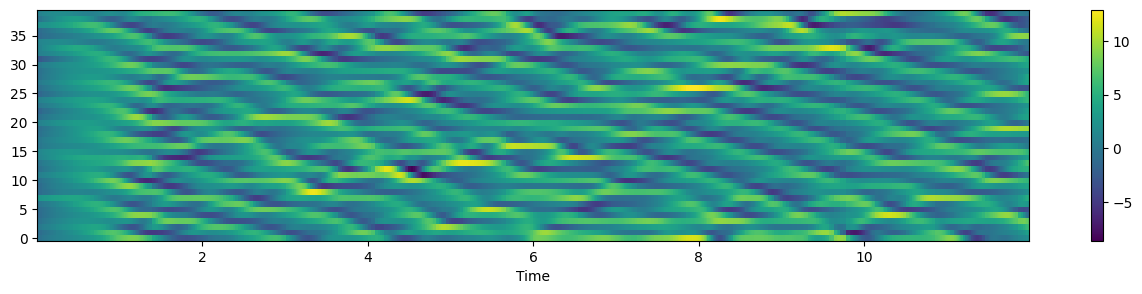

In [3]:
# Generate a time series from the defined initial_condition using our L96 simulator
forward_operator = L96Simulator(forcing=8.0) # F = 8

# We specify the integration time and number of time steps, then randomly sample these time steps from a uniform distribution
integration_time = 12
n_time_steps = 1200
mean_time_step = integration_time / n_time_steps # 0.01 in this setting
forecast_steps = torch.rand(n_time_steps) * integration_time
forecast_steps = torch.sort(forecast_steps).values
forecast_steps = torch.unique_consecutive(forecast_steps) # remove potential duplicated values

# We solve the L96 equations with Runge-Kutta 4, using the specified irregular time steps
ts = forward_operator.integrate(time=forecast_steps, state=initial_state.fields['x'].reshape(1, -1)).squeeze()

print(ts.shape)
show_1dseqimg_irregular_time(ts.T, forecast_steps, x_label="Time")

# We burn out the beginning of the time series in order to deal with data that are in the stationary distribution of the system
cutoff_time = 4
cutoff_index = int(cutoff_time / mean_time_step)
print(forecast_steps[cutoff_index])
true_ts = ts[cutoff_index:]
true_initial_state = true_ts[0]
forecast_steps = forecast_steps[cutoff_index:] - forecast_steps[cutoff_index]

true_ts = State(true_ts.reshape(1, -1, n_variables), time_axis=forecast_steps)

We now add some Gaussian noise and a binary mask on the true time series, in order to generate corresponding observations.

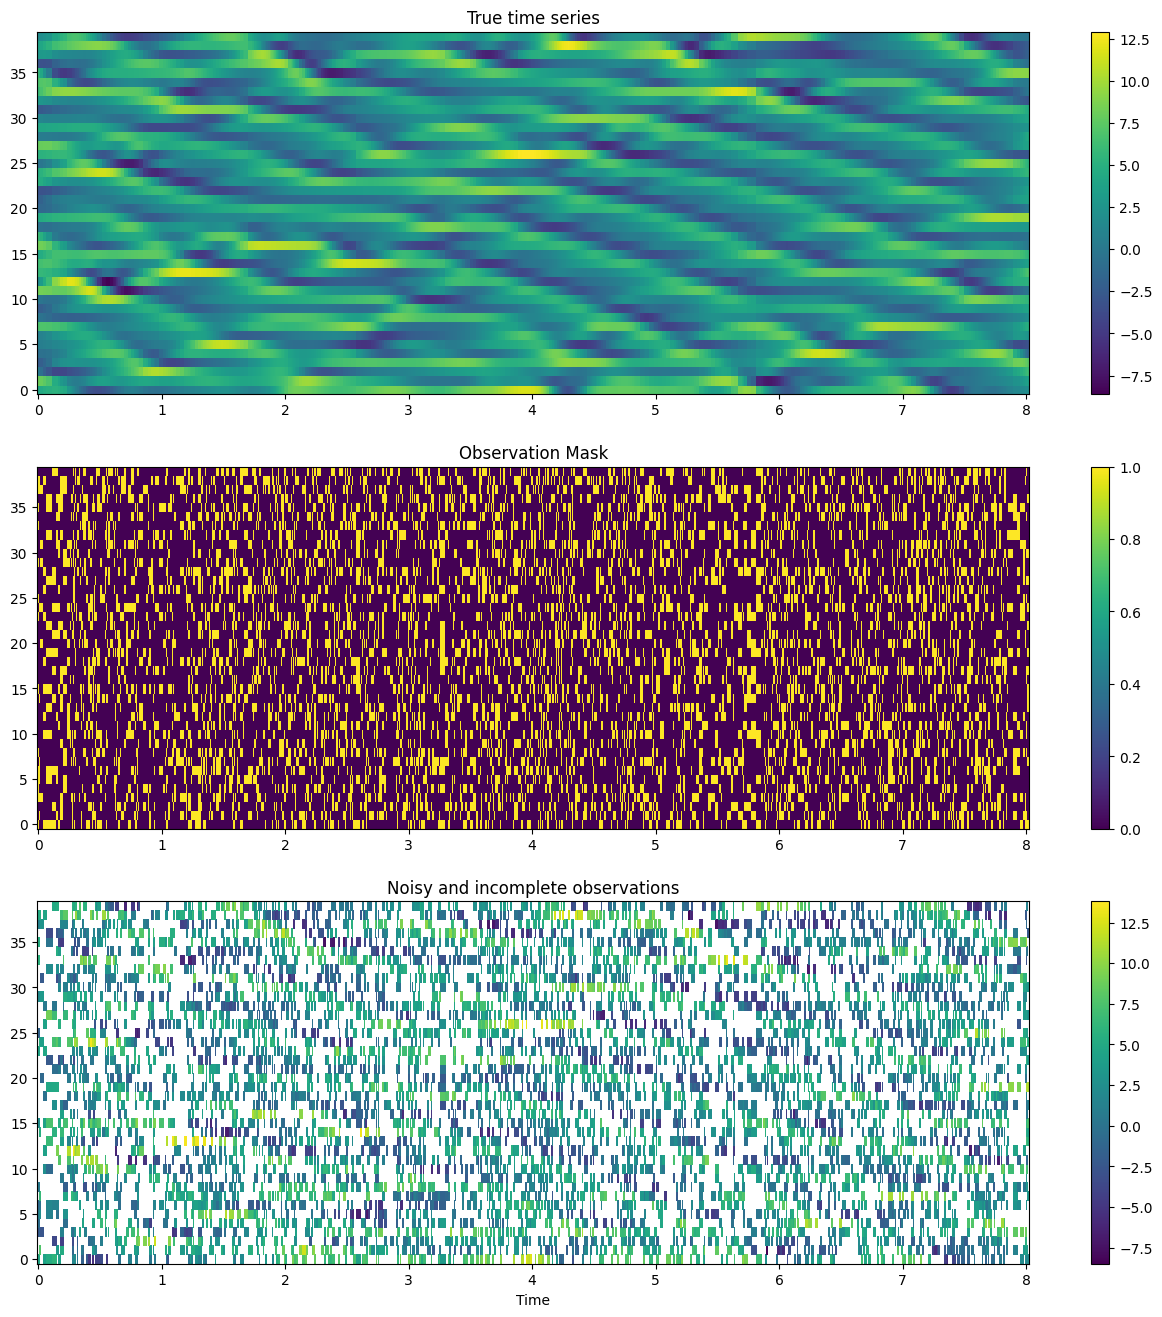

In [4]:
noise_amplitude = 1.0  # observation noise s.d.
p_obs = 0.25 # 75% of the variables are masked

groundtruth, obs_op, observations = random_sparse_noisy_obs(true_ts, noise_amplitude, p_obs)

valid_obs = observations.state.fields['x'][0].T
valid_obs[torch.logical_not(observations.mask.fields['x'][0].T)] = torch.nan

fig, ax = plt.subplots(3, 1, figsize=(16,16))

show_1dseqimg_irregular_time(true_ts.fields['x'][0].T, forecast_steps, ax=ax[0], title="True time series")
show_1dseqimg_irregular_time(observations.mask.fields['x'][0].T, forecast_steps, ax=ax[1], title="Observation Mask")
show_1dseqimg_irregular_time(valid_obs, forecast_steps, ax=ax[2], title="Noisy and incomplete observations", x_label="Time")

In [5]:
# we define a simple one-time-step function in order to fit the ADDA conventions
# In order to use the 4D-Var function, you should always have a function like this taking the state, dt, dynamic_inputs and static_inputs

def next_step_function(x: State, dt: float, dynamic_inputs: State, static_inputs: State):
    "this time stepping function expects the input State x to have a single field called 'x'"
    B, T = x.fields.batch_size[:2]
    x_tensor = x.fields.reshape(-1)["x"]  # combine batch and time dimensions, leave others intact
    integrated = forward_operator.integrate(torch.arange(2) * dt, x_tensor)[:, 1]
    integrated = integrated.unsqueeze(0)  # re-add batch dimension
    new_fields = TensorDict(x=integrated, batch_size=(1, T))
    return State(new_fields, time_axis=x.time_axis + dt)  # return State object, advancing time

# Strong-constraint 4D-Var

Let us now implement the strong-constraint 4D-Var assimilation scheme to try to reconstruct the full time series from the noisy and incomplete observations.

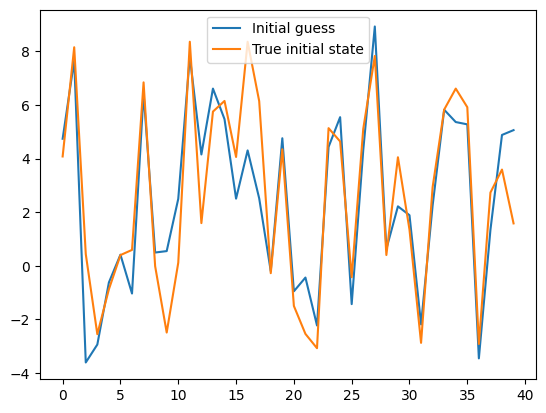

In [6]:
# we build an initial guess for the initial state, using the available observations
# We simply use the first available observation for each channel
initialization = naive_initialization(observations)  # state estimate for all time points
initialization = initialization[:, :1]  # first time point only

plt.plot(initialization.fields['x'].squeeze(), label='Initial guess')
plt.plot(true_initial_state, label='True initial state')
plt.legend()

In [7]:
n_obs_steps = 100 # we assimilate only on the earliest time steps, otherwise the optimization would be too unstable
time_window = (observations.state.time_axis[0], observations.state.time_axis[n_obs_steps])

obs_op_opt = obs_op.restrict_time_domain(*time_window)
observations_opt = observations.restrict_time_domain(*time_window)

print(obs_op_opt.mask.time_axis) # one can clearly see that the times of observations are irregularly sampled

tensor([0.0000, 0.0143, 0.0283, 0.0559, 0.0851, 0.1508, 0.1512, 0.1700, 0.1965,
        0.2068, 0.2103, 0.2604, 0.2642, 0.2709, 0.2765, 0.2850, 0.2873, 0.2910,
        0.2915, 0.2956, 0.3123, 0.3131, 0.3176, 0.3230, 0.3405, 0.3430, 0.3579,
        0.3596, 0.3687, 0.3709, 0.3736, 0.4023, 0.4194, 0.4321, 0.4400, 0.4445,
        0.4498, 0.4568, 0.4646, 0.4693, 0.4723, 0.4957, 0.5074, 0.5391, 0.5428,
        0.5434, 0.5442, 0.5596, 0.5675, 0.5697, 0.5704, 0.5976, 0.6143, 0.6193,
        0.6247, 0.6389, 0.6413, 0.6462, 0.6579, 0.6666, 0.6805, 0.7096, 0.7168,
        0.7435, 0.7671, 0.7850, 0.7857, 0.7909, 0.7971, 0.8038, 0.8137, 0.8342,
        0.8747, 0.8797, 0.9029, 0.9035, 0.9299, 0.9306, 0.9320, 0.9444, 0.9548,
        1.0068, 1.0283, 1.0307, 1.0312, 1.0456, 1.0461, 1.0632, 1.0824, 1.0884,
        1.1043, 1.1076, 1.1360, 1.1603, 1.2015, 1.2049, 1.2115, 1.2204, 1.2388,
        1.2488])


In [8]:
t0 = time()
assimilated_ic = sc4dvar_single_window(next_step_function, 
                                       observations_opt, 
                                       obs_op_opt, 
                                       initialization,
                                       n_steps=10,                                        
                                       optimizer_pars={'lr': 1e-1})                                     
print(f'Total time for the 4D-Var optimization: {time() - t0} seconds')

Total time for the 4D-Var optimization: 40.99651765823364 seconds


Here we display the assimilated initial state of the trajectory and compare it to the initialization of the 4D-Var optimization.

Initial guess MSE: 2.694873332977295
Assimilated state MSE: 0.19625836610794067


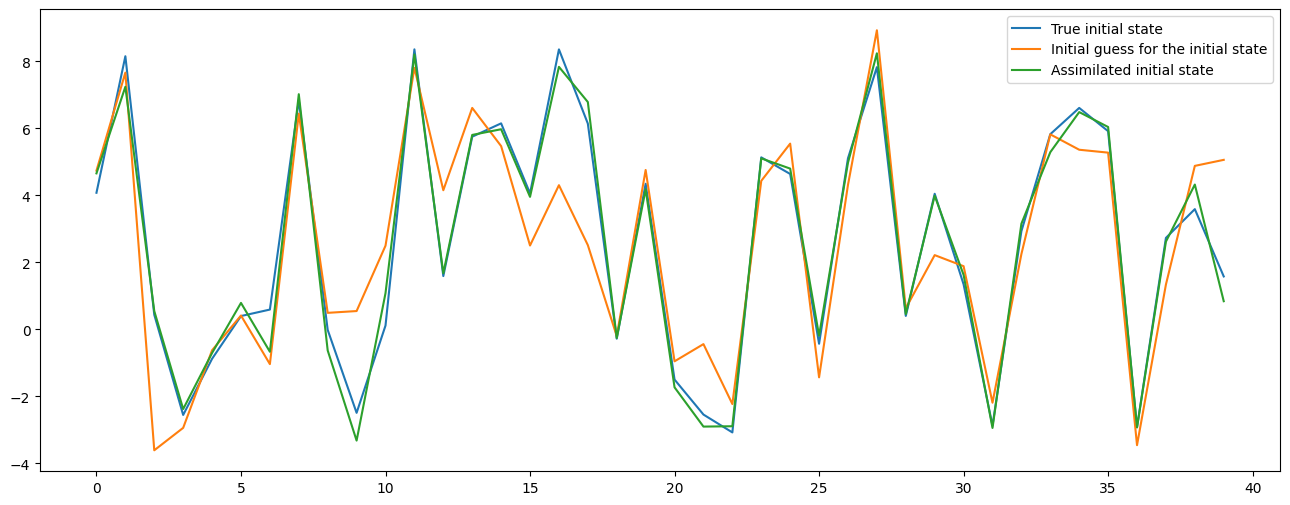

In [9]:
plt.figure(figsize=(16,6))
plt.plot(true_initial_state, label='True initial state')
plt.plot(initialization.fields['x'].squeeze(), label='Initial guess for the initial state')
plt.plot(assimilated_ic.fields['x'].squeeze().detach(), label='Assimilated initial state')
plt.legend()

MSE0 = torch.mean((initialization.fields['x'].squeeze() - true_initial_state) **2)
MSE = torch.mean((assimilated_ic.fields['x'].squeeze() - true_initial_state) **2)

print(f'Initial guess MSE: {MSE0}')
print(f'Assimilated state MSE: {MSE}')

We finally compute a rollout trajectory from the assimilated initial state and compare it to the groundtruth.

In [10]:
# rollout from assimilated state
assimilated_trajectory = forward_operator.integrate(time=forecast_steps, state=assimilated_ic.fields['x'][0]).squeeze().cpu().detach()

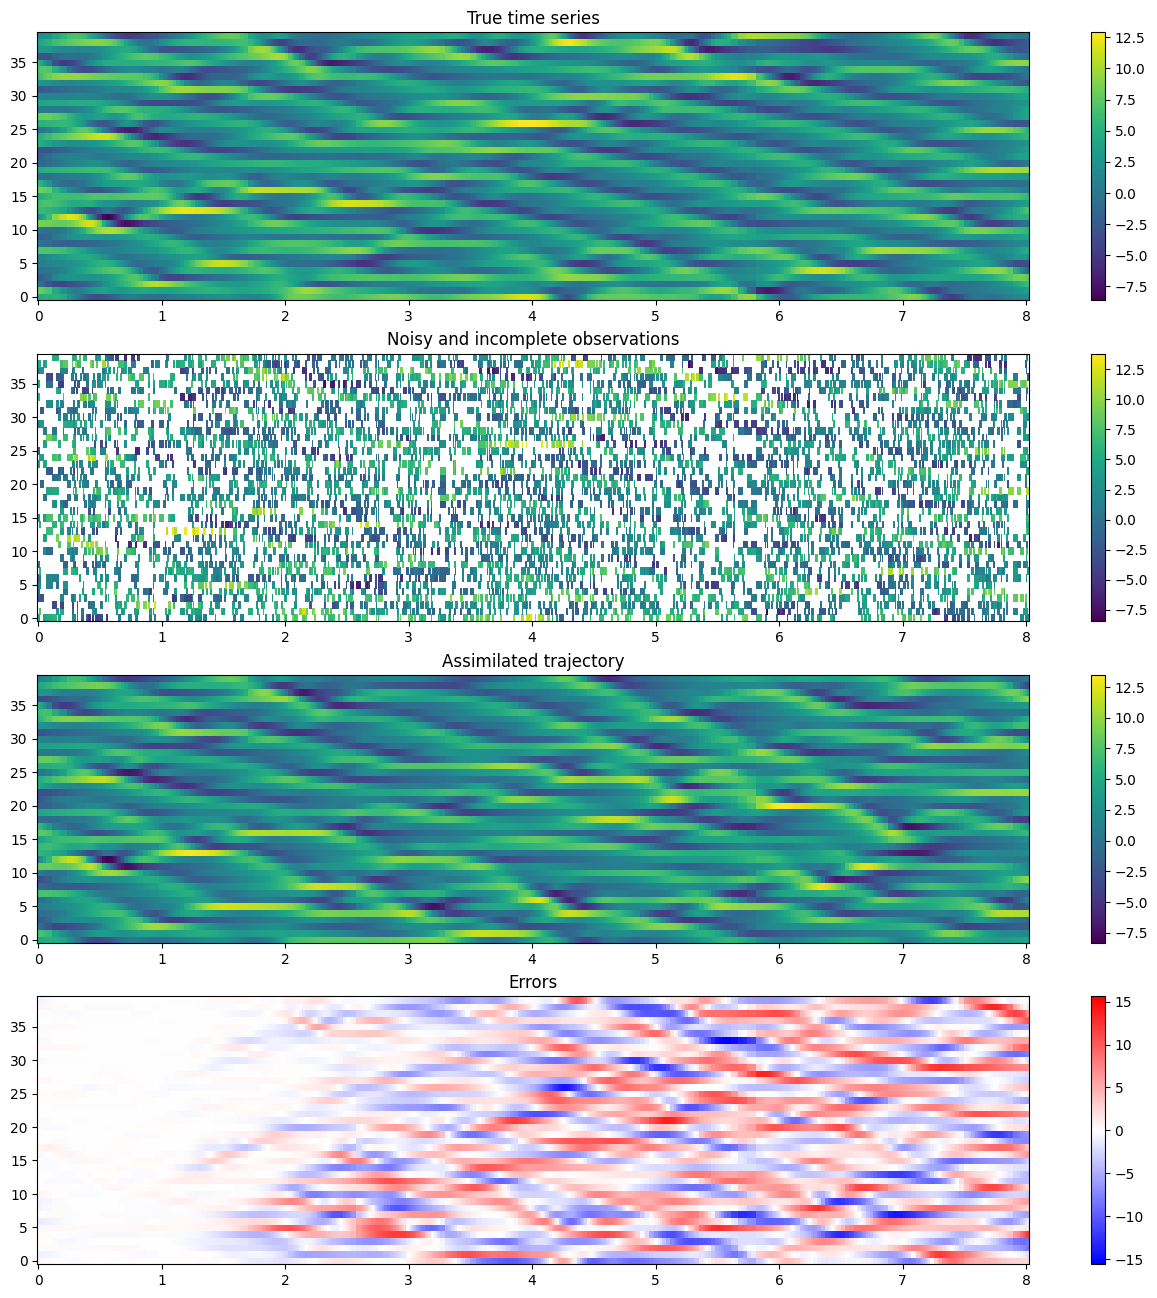

In [11]:
errors = (assimilated_trajectory - true_ts.fields['x'].squeeze())

fig, ax = plt.subplots(4, 1, figsize=(16,16))
show_1dseqimg_irregular_time(true_ts.fields['x'][0].T, forecast_steps, ax=ax[0], title="True time series")
show_1dseqimg_irregular_time(valid_obs, forecast_steps, ax=ax[1], title="Noisy and incomplete observations")
show_1dseqimg_irregular_time(assimilated_trajectory.T, forecast_steps, ax=ax[2], title="Assimilated trajectory")
show_1dseqimg_irregular_time(errors.T, forecast_steps, ax=ax[3], title="Errors", cmap="bwr", center_on_zero=True)

torch.Size([800])


Text(0, 0.5, 'RMSE')

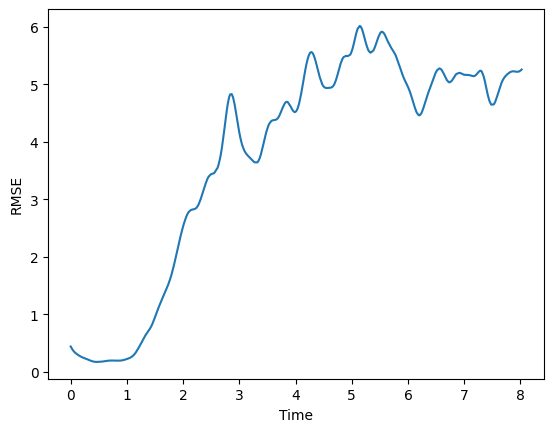

In [12]:
RMSE_over_time = torch.sqrt((errors ** 2).mean(dim=1))
print(RMSE_over_time.shape)

fig, ax = plt.subplots()
plt.plot(forecast_steps, RMSE_over_time)
ax.set_xlabel('Time')
ax.set_ylabel('RMSE')

After 2 to 3 seconds the RMSE explodes, which is to be expected for a chaotic system like Lorenz-96.

# Weak-constraint 4D-Var

We now solve the same assimilation problem with a weak-constraint approach.

We again define an initialization for the assimilated state, this time defined over the whole time series.

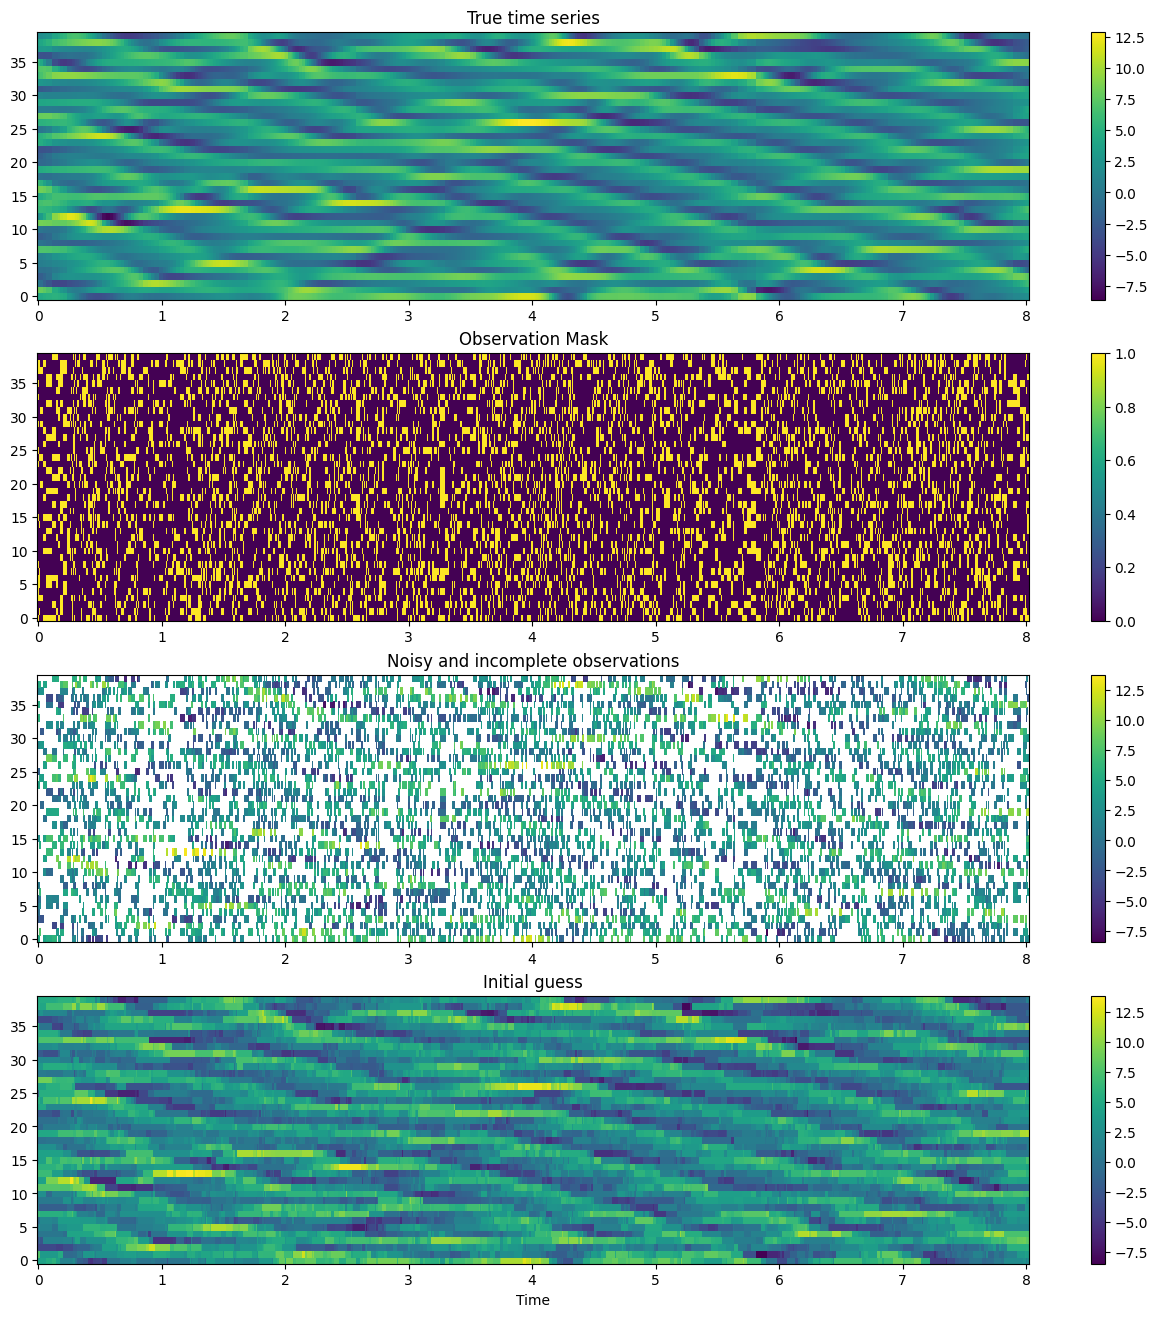

In [13]:
# we build an initial guess for the initial state, using the available observations
# We simply use the first available observation for each channel
initialization = naive_initialization(observations)  # state estimate for all time points
fig, ax = plt.subplots(4, 1, figsize=(16,16))

show_1dseqimg_irregular_time(true_ts.fields['x'][0].T, forecast_steps, ax=ax[0], title="True time series")
show_1dseqimg_irregular_time(observations.mask.fields['x'][0].T, forecast_steps, ax=ax[1], title="Observation Mask")
show_1dseqimg_irregular_time(valid_obs, forecast_steps, ax=ax[2], title="Noisy and incomplete observations")
show_1dseqimg_irregular_time(initialization.fields['x'][0].T, forecast_steps, ax=ax[3], title="Initial guess", x_label="Time")

For the purpose of parallel computation of the assimilation cost, we need the assimilated state to have a regular time axis.
Thus, we interpolate our initialization on a regular grid.

In [14]:
dt = 0.01 # The time step of our regular grid for the assimilated state

left_bound, right_bound = obs_op.time_axis[0], obs_op.time_axis[-1] + dt
interpolated_init_time_axis = torch.arange(left_bound, right_bound, dt, dtype=torch.float64)
n_steps_interp = interpolated_init_time_axis.nelement()
interpolated_init_tensor = torch.zeros((1, n_steps_interp, n_variables))
for i in range(n_variables):
    interpolated_init_tensor[0,:,i] = torch.Tensor(np.interp(interpolated_init_time_axis, initialization.time_axis, initialization.fields["x"][0,:,i]))
interpolated_init = State(TensorDict(x=interpolated_init_tensor, batch_size=[1, n_steps_interp]), 
                          time_axis=interpolated_init_time_axis)

Now we define the distribution on model errors.

In [15]:
n_steps = interpolated_init.time_axis.nelement()

model_error_distribs = DiagonalGaussian(torch.zeros(1, n_steps - 1, n_variables), 
                                        torch.ones(1, n_steps - 1, n_variables))

For the optimization, we use a different observation operator, which enables to interpolate the assimilated state to the observation timestamps at each optimization step.

In [16]:
obs_op_opt = MaskedIidGaussianTimeInterpolatedObsOp(obs_op.mask, obs_op.sigma, obs_op.sample_points)

We finally perform weak-constraint 4D-Var.

In [17]:
t0 = time()
assimilated_states = wc4dvar_single_window(next_step_function, 
                                           observations, 
                                           obs_op_opt, 
                                           model_error_distribs,
                                           x_init=interpolated_init,
                                           #dt=mean_time_step,
                                           optimizer_pars={'lr': 1},
                                           alpha=1e4,
                                           n_steps=50,
                                           verbose=0)
print(f'Total time for the 4D-Var optimization: {time() - t0} seconds')

assimilated_states = assimilated_states.detach()

Total time for the 4D-Var optimization: 27.483289003372192 seconds


Here we display the assimilated initial state of the trajectory and compare it to the initialization of the 4D-Var optimization.

Initial guess MSE: 2.694873332977295
Assimilated state MSE: 0.22899799048900604


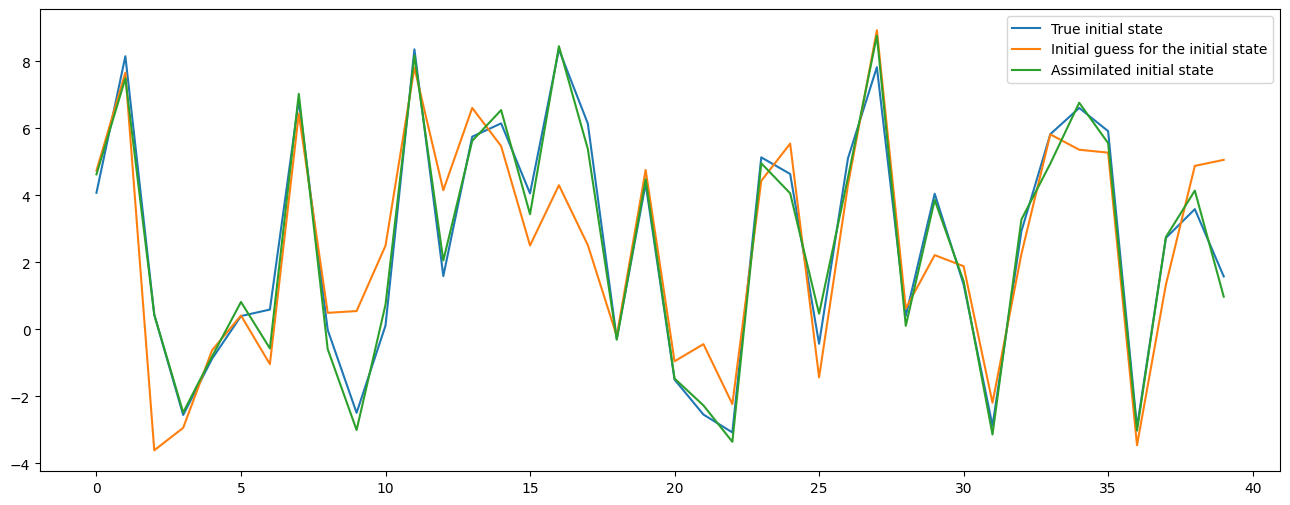

In [18]:
assimilated_initial_state = assimilated_states.fields['x'][0,0]

plt.figure(figsize=(16,6))
plt.plot(true_initial_state, label='True initial state')
plt.plot(initialization.fields['x'][0,0], label='Initial guess for the initial state')
plt.plot(assimilated_states.fields['x'][0,0], label='Assimilated initial state')
plt.legend()

MSE0 = torch.mean((initialization.fields['x'][0,0] - true_initial_state) **2)
MSE = torch.mean((assimilated_states.fields['x'][0,0] - true_initial_state) **2)

print(f'Initial guess MSE: {MSE0}')
print(f'Assimilated state MSE: {MSE}')

Let us now visualise the full assimilated trajectory and its difference to the groundtruth.

torch.Size([800, 40])


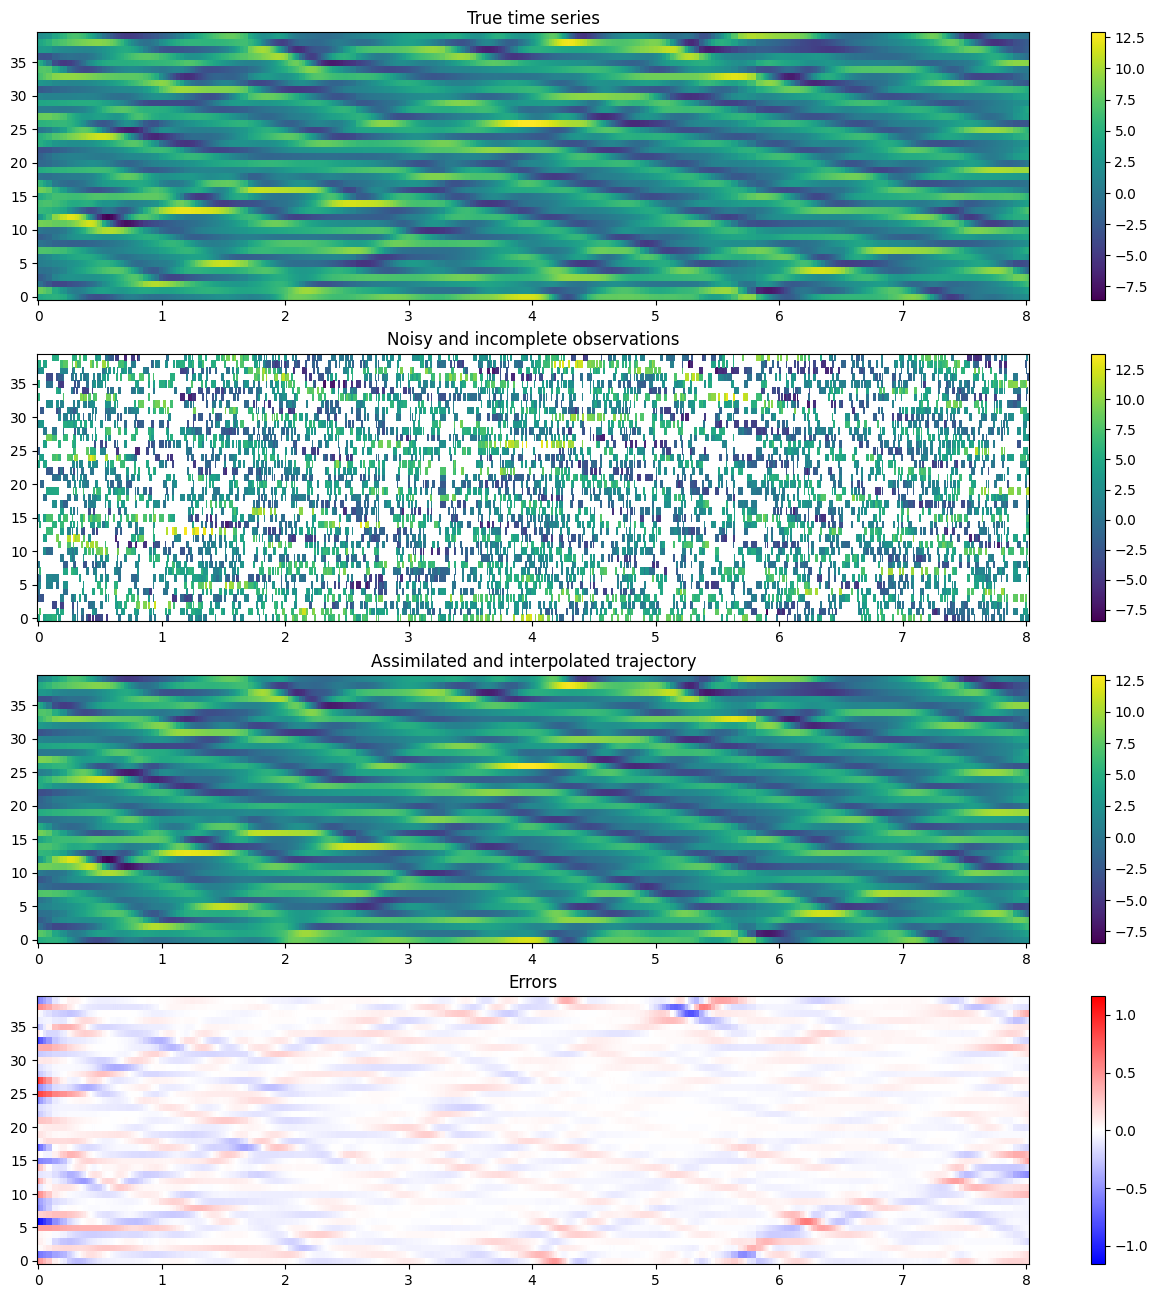

In [19]:
interpolated_assimilated_tensor = torch.zeros((1, true_ts.time_axis.nelement(), n_variables))
for i in range(n_variables):
    interpolated_assimilated_tensor[0,:,i] = torch.Tensor(np.interp(true_ts.time_axis, assimilated_states.time_axis, assimilated_states.fields["x"][0,:,i]))
interpolated_assimilated = State(TensorDict(x=interpolated_assimilated_tensor, batch_size=[1, true_ts.time_axis.nelement()]), 
                          time_axis=true_ts.time_axis)

errors = (interpolated_assimilated - true_ts).fields['x'][0]
print(errors.shape)
vmax_abs = torch.max(torch.abs(errors))

fig, ax = plt.subplots(4, 1, figsize=(16,16))
show_1dseqimg_irregular_time(true_ts.fields['x'][0].T, forecast_steps, ax=ax[0], title="True time series")
show_1dseqimg_irregular_time(valid_obs, forecast_steps, ax=ax[1], title="Noisy and incomplete observations")
show_1dseqimg_irregular_time(interpolated_assimilated.fields['x'][0].T, forecast_steps, ax=ax[2], title="Assimilated and interpolated trajectory")
show_1dseqimg_irregular_time(errors.T, forecast_steps, ax=ax[3], title="Errors", cmap="bwr", center_on_zero=True)

Finally one can see that the RMSE is higher on the edges of the assimilation window than in the middle.

torch.Size([800])


Text(0, 0.5, 'RMSE')

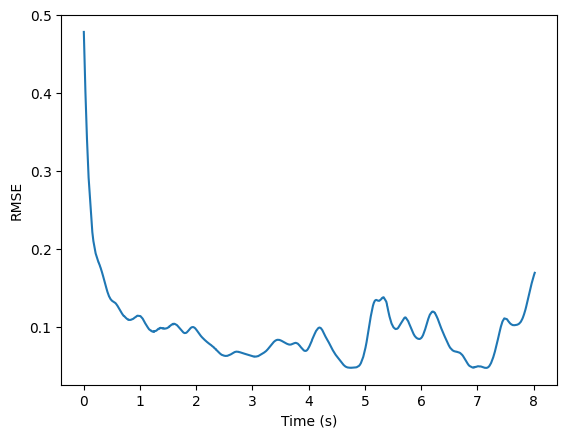

In [20]:
RMSE_over_time = torch.sqrt((errors ** 2).mean(dim=1))

print(RMSE_over_time.shape)

fig, ax = plt.subplots()
plt.plot(true_ts.time_axis, RMSE_over_time)
ax.set_xlabel('Time (s)')
ax.set_ylabel('RMSE')

# Ensemble Kalman filter

Finally, we now solve the same assimilation problem with an EnKF.

In [21]:
# we introduce a variant of the previous next-step function, which accounts for the batch dimension of the input.

def next_step_function(x: State, dt: float, dynamic_inputs: State, static_inputs: State):
    "this time stepping function expects the input State x to have a single field called 'x'"
    B, T = x.fields.batch_size[:2]
    integrated = forward_operator.integrate(torch.arange(2) * dt, x.fields["x"])[:, -1, :] # integrate over a time step, take the current time
    integrated = integrated.unsqueeze(1)  # re-add time dimension
    new_fields = TensorDict(x=integrated, batch_size=(B, T))
    return State(new_fields, time_axis=x.time_axis + dt)  # return State object, advancing time

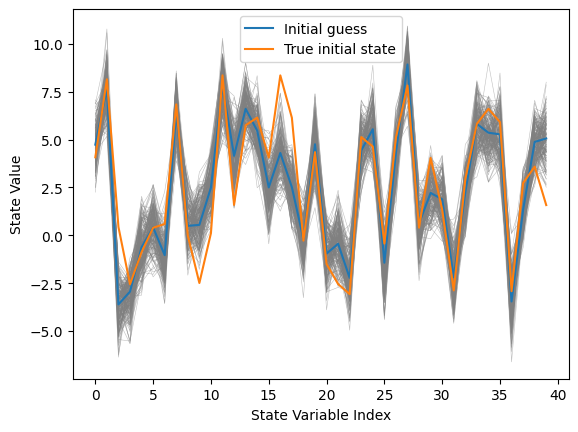

In [22]:
initialization = naive_initialization(observations)  # state estimate for all time points
initialization = initialization[:,:1]  # first time point only
number_of_members = 200
initial_ensemble_std = 1.0
enkf_obj = EnKF(n_members=number_of_members, n_variables=initialization.fields["x"].shape[-1], initial_ensemble_std=initial_ensemble_std)
enkf_obj.initialize_ensemble(initialization)
# plot 200 ensemble members
for i in range(number_of_members):
    plt.plot(enkf_obj.ensemble.fields['x'][i, 0], alpha=0.5, c='gray', linewidth=0.4)
plt.plot(initialization.fields['x'].squeeze(), label='Initial guess')
plt.plot(true_ts.fields['x'][0, 0], label='True initial state')
plt.xlabel('State Variable Index')
plt.ylabel('State Value')
plt.legend()

In [23]:
# Run data assimilation
ensemble_states = enkf(
        m_dyn=next_step_function,
        observations=observations,
        obs_op=obs_op,
        x_init=initialization,
        n_members=number_of_members,
        initial_ensemble_std=initial_ensemble_std,
    )

print(f"EnKF assimilation completed!")

EnKF assimilation completed!


torch.Size([800, 40])


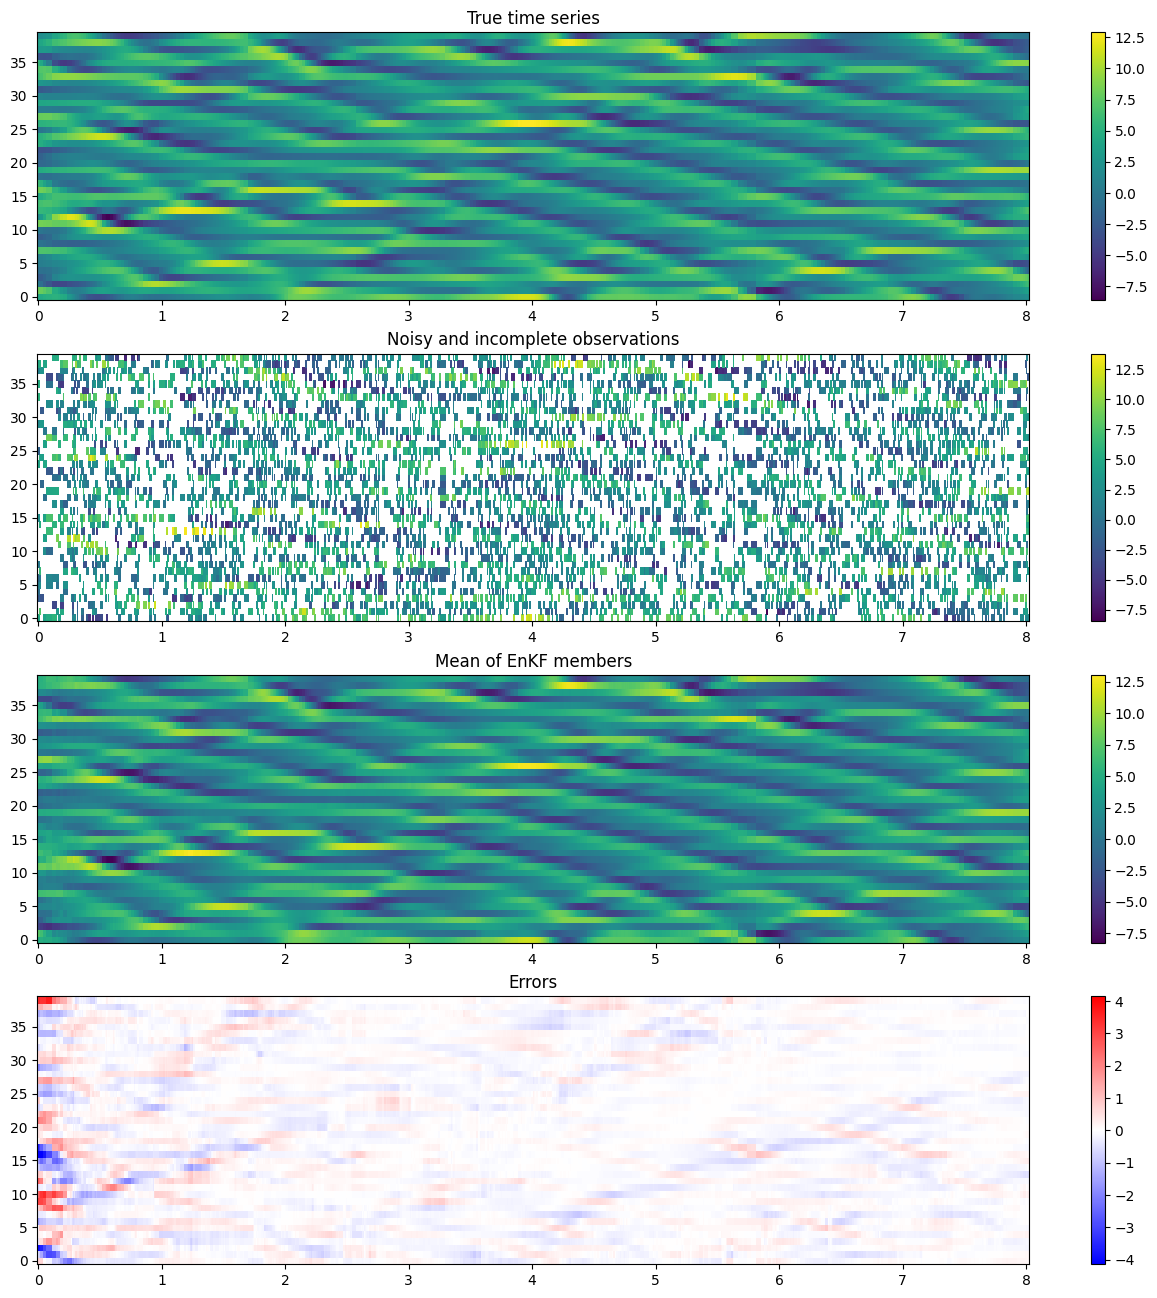

In [24]:
ensemble_mean = torch.mean(ensemble_states.fields["x"], dim=0)
print(ensemble_mean.shape)

errors = ensemble_mean - true_ts.fields['x'][0]
vmax_abs = torch.max(torch.abs(errors))

fig, ax = plt.subplots(4, 1, figsize=(16,16))
show_1dseqimg_irregular_time(true_ts.fields['x'][0].T, forecast_steps, ax=ax[0], title="True time series")
show_1dseqimg_irregular_time(valid_obs, forecast_steps, ax=ax[1], title="Noisy and incomplete observations")
show_1dseqimg_irregular_time(ensemble_mean.T, forecast_steps, ax=ax[2], title="Mean of EnKF members")
show_1dseqimg_irregular_time(errors.T, forecast_steps, ax=ax[3], title="Errors", cmap="bwr", center_on_zero=True)

One can see that, despite presenting large errors in the beginning of the observation window, the EnKF analysis gives a reasonably good estimation of the true state.